<a href="https://colab.research.google.com/github/angioitoan2409/flood_forecasting/blob/main/01_capacity_baseline_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
BASE_DIR = "/content/drive/MyDrive/flood_forecasting"
MODEL_DIR = f"{BASE_DIR}/model_inputs"

print(os.listdir(MODEL_DIR))

['dtm.tif', 'sealed_fraction.tif', 'buildings.tif', 'nonsealed_fraction.tif', 'manning_n.tif', 'radolan_aligned', 'MS5_mask.tif', 'MS2_mask.tif']


##Baseline capacity-based drainage model

###Imports

In [3]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

###Load static rasters

In [4]:
def load_raster(path):
    with rasterio.open(path) as src:
        return src.read(1), src.nodata

dtm, dtm_nodata       = load_raster(f"{MODEL_DIR}/dtm.tif")
buildings, _          = load_raster(f"{MODEL_DIR}/buildings.tif")
sealed, _             = load_raster(f"{MODEL_DIR}/sealed_fraction.tif")
nonsealed, _          = load_raster(f"{MODEL_DIR}/nonsealed_fraction.tif")
ms2_mask              = load_raster(f"{MODEL_DIR}/MS2_mask.tif")[0] == 1
ms5_mask              = load_raster(f"{MODEL_DIR}/MS5_mask.tif")[0] == 1

domain_mask   = dtm != dtm_nodata
building_mask = buildings == 1
ground_mask   = domain_mask & ~building_mask

CELL_AREA_M2 = 25.0  # 5m x 5m

print("Rasters loaded. Domain cells:", domain_mask.sum(),
      "| Building cells:", building_mask.sum(),
      "| MS2 cells:", ms2_mask.sum(), "| MS5 cells:", ms5_mask.sum())


Rasters loaded. Domain cells: 1824968 | Building cells: 359335 | MS2 cells: 46940 | MS5 cells: 8338


###Parameters

In [5]:
PARAM_SETS = {
    "run1": dict(infiltration_mm_h=10, sewer_mm_h=20, threshold_mm=5),
    "run2": dict(infiltration_mm_h=10, sewer_mm_h=25, threshold_mm=5),
    "run3": dict(infiltration_mm_h=10, sewer_mm_h=20, threshold_mm=2),
    "run4": dict(infiltration_mm_h=10, sewer_mm_h=25, threshold_mm=2),
}

###Function

In [6]:
def run_capacity_model(rain_stack, dt_minutes, params):
    """
    rain_stack: (n_t, H, W) rainfall in mm per timestep
    Returns per-timestep series: roof, sewer, infiltration, ms2_total, ms5_total (m3/5min)
    """
    n_t, H, W = rain_stack.shape
    ponding = np.zeros((H, W), dtype=np.float32)

    sewer_cap_per_step = params["sewer_mm_h"] * dt_minutes / 60.0 * sealed
    infil_cap_per_step = params["infiltration_mm_h"] * dt_minutes / 60.0 * nonsealed
    threshold = params["threshold_mm"]

    roof_series  = np.zeros(n_t)
    sewer_series = np.zeros(n_t)
    infil_series = np.zeros(n_t)
    ms2_series   = np.zeros(n_t)
    ms5_series   = np.zeros(n_t)

    for t in range(n_t):
        rain_t = rain_stack[t]

        roof_drained = np.where(building_mask, rain_t, 0.0)

        ponding[ground_mask] += rain_t[ground_mask]

        active = ponding > threshold
        sewer_drained = np.where(active & ground_mask,
                                  np.minimum(sewer_cap_per_step, ponding), 0.0)

        remaining = ponding - sewer_drained
        infil_drained = np.where(ground_mask,
                                  np.minimum(infil_cap_per_step, np.maximum(remaining, 0)), 0.0)

        ponding = np.maximum(ponding - sewer_drained - infil_drained, 0.0)

        roof_vol  = roof_drained  * CELL_AREA_M2 / 1000.0
        sewer_vol = sewer_drained * CELL_AREA_M2 / 1000.0
        infil_vol = infil_drained * CELL_AREA_M2 / 1000.0

        roof_series[t]  = roof_vol.sum()
        sewer_series[t] = sewer_vol.sum()
        infil_series[t] = infil_vol.sum()

        total_drain_this_step = roof_vol + sewer_vol
        ms2_series[t] = total_drain_this_step[ms2_mask].sum()
        ms5_series[t] = total_drain_this_step[ms5_mask].sum()

    return dict(roof=roof_series, sewer=sewer_series, infiltration=infil_series,
                ms2_total=ms2_series, ms5_total=ms5_series)

##Test

###One event

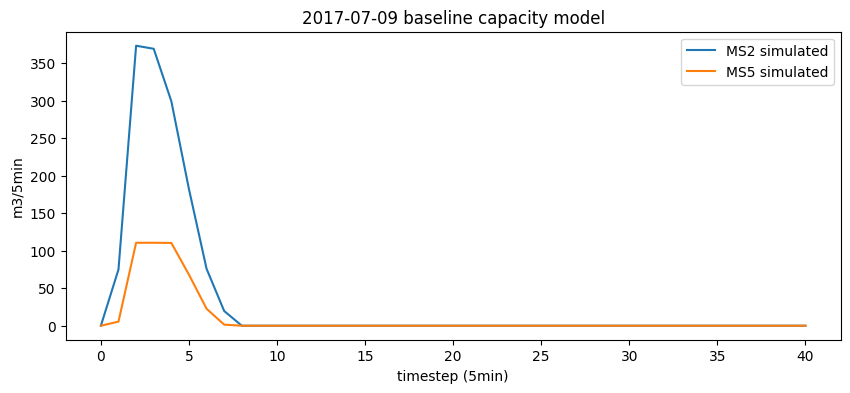

In [7]:
d = np.load(f"{MODEL_DIR}/radolan_aligned/2017-07-09_aligned.npz", allow_pickle=True)
rain_stack = d["rain_mm"]

result = run_capacity_model(rain_stack, dt_minutes=5, params=PARAM_SETS["run1"])

plt.figure(figsize=(10,4))
plt.plot(result["ms2_total"], label="MS2 simulated")
plt.plot(result["ms5_total"], label="MS5 simulated")
plt.legend(); plt.ylabel("m3/5min"); plt.xlabel("timestep (5min)")
plt.title("2017-07-09 baseline capacity model")
plt.show()

In [8]:
import numpy as np
import rasterio

MODEL_DIR = "/content/drive/MyDrive/flood_forecasting/model_inputs"

def load_raster(path):
    with rasterio.open(path) as src:
        return src.read(1), src.nodata

dtm, dtm_nodata = load_raster(f"{MODEL_DIR}/dtm.tif")
buildings, _    = load_raster(f"{MODEL_DIR}/buildings.tif")
sealed, _       = load_raster(f"{MODEL_DIR}/sealed_fraction.tif")
ms2_mask        = load_raster(f"{MODEL_DIR}/MS2_mask.tif")[0] == 1
ms5_mask        = load_raster(f"{MODEL_DIR}/MS5_mask.tif")[0] == 1
domain_mask     = dtm != dtm_nodata
building_mask   = buildings == 1
ground_mask     = domain_mask & ~building_mask

# ---- 1. Sealed fraction & building density comparison ----
def zone_stats(mask, name):
    ground_in_zone = mask & ground_mask
    n_ground = ground_in_zone.sum()
    n_building = (mask & building_mask).sum()
    n_total = mask.sum()
    mean_sealed = sealed[ground_in_zone].mean() if n_ground > 0 else np.nan
    building_frac = n_building / n_total if n_total > 0 else np.nan
    print(f"{name}: total_cells={n_total}, building_frac={building_frac:.2%}, "
          f"mean_sealed_fraction(ground cells)={mean_sealed:.3f}")

print("=== Surface composition comparison ===")
zone_stats(ms2_mask, "MS2")
zone_stats(ms5_mask, "MS5")
zone_stats(domain_mask, "Whole domain")

# ---- 2. Rainfall over each footprint, for the test event ----
print("\n=== Rainfall over each footprint (2017-07-09 event) ===")
d = np.load(f"{MODEL_DIR}/radolan_aligned/2017-07-09_aligned.npz", allow_pickle=True)
rain_stack = d["rain_mm"]

mean_rain_ms2 = rain_stack[:, ms2_mask].mean(axis=1)
mean_rain_ms5 = rain_stack[:, ms5_mask].mean(axis=1)

print(f"MS2: peak per-cell-mean rainfall = {mean_rain_ms2.max():.2f} mm/5min, "
      f"total event rainfall = {mean_rain_ms2.sum():.2f} mm")
print(f"MS5: peak per-cell-mean rainfall = {mean_rain_ms5.max():.2f} mm/5min, "
      f"total event rainfall = {mean_rain_ms5.sum():.2f} mm")

ratio = mean_rain_ms5.sum() / mean_rain_ms2.sum()
print(f"\nMS5-to-MS2 total rainfall ratio: {ratio:.2f} "
      f"(far from 1.0 = RADOLAN input itself differs meaningfully between footprints)")

=== Surface composition comparison ===
MS2: total_cells=46940, building_frac=29.21%, mean_sealed_fraction(ground cells)=0.441
MS5: total_cells=8338, building_frac=31.46%, mean_sealed_fraction(ground cells)=0.464
Whole domain: total_cells=1824968, building_frac=0.00%, mean_sealed_fraction(ground cells)=0.255

=== Rainfall over each footprint (2017-07-09 event) ===
MS2: peak per-cell-mean rainfall = 1.83 mm/5min, total event rainfall = 5.54 mm
MS5: peak per-cell-mean rainfall = 2.01 mm/5min, total event rainfall = 6.82 mm

MS5-to-MS2 total rainfall ratio: 1.23 (far from 1.0 = RADOLAN input itself differs meaningfully between footprints)


MS5 peak — run1 (20mm/h): 110.6 m3/5min
MS5 peak — run2 (25mm/h): 138.2 m3/5min
Ratio: 1.250 (expected ~1.25 if capacity-limited)

MS2 peak — run1 (20mm/h): 373.2 m3/5min
MS2 peak — run2 (25mm/h): 466.5 m3/5min


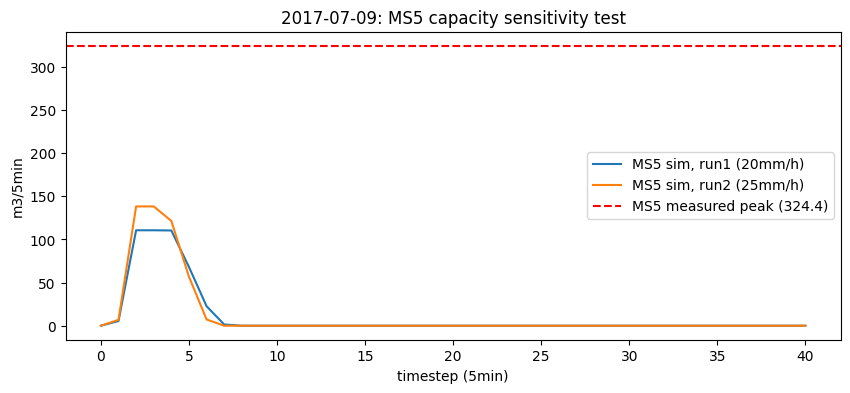

In [9]:
result_run1 = run_capacity_model(rain_stack, dt_minutes=5, params=PARAM_SETS["run1"])
result_run2 = run_capacity_model(rain_stack, dt_minutes=5, params=PARAM_SETS["run2"])

print(f"MS5 peak — run1 (20mm/h): {result_run1['ms5_total'].max():.1f} m3/5min")
print(f"MS5 peak — run2 (25mm/h): {result_run2['ms5_total'].max():.1f} m3/5min")
print(f"Ratio: {result_run2['ms5_total'].max() / result_run1['ms5_total'].max():.3f} "
      f"(expected ~1.25 if capacity-limited)")

print()
print(f"MS2 peak — run1 (20mm/h): {result_run1['ms2_total'].max():.1f} m3/5min")
print(f"MS2 peak — run2 (25mm/h): {result_run2['ms2_total'].max():.1f} m3/5min")

import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.plot(result_run1["ms5_total"], label="MS5 sim, run1 (20mm/h)")
plt.plot(result_run2["ms5_total"], label="MS5 sim, run2 (25mm/h)")
plt.axhline(324.4, color="red", linestyle="--", label="MS5 measured peak (324.4)")
plt.legend(); plt.ylabel("m3/5min"); plt.xlabel("timestep (5min)")
plt.title("2017-07-09: MS5 capacity sensitivity test")
plt.show()

###Eight events

In [15]:
import pandas as pd

MSD_DIR = f"{BASE_DIR}/val/msd"

def load_msd_event(filename):
    path = f"{MSD_DIR}/{filename}"
    df = pd.read_csv(path)
    df["time"] = pd.to_datetime(df["time"])
    df = df.groupby("time", as_index=True).agg(
        lambda s: s.dropna().iloc[0] if s.notna().any() else np.nan
    )
    df_5min = df.resample("5min").mean()
    for col in ["ms2", "ms5", "ms2_before"]:
        df_5min[col + "_m3_per_5min"] = df_5min[col] * 300
    return df_5min

In [22]:
import time

def coverage_adjusted_sum(series):
    """Scale up the sum to account for missing timesteps, assuming missing
    periods have similar average intensity to observed ones."""
    coverage = series.notna().mean()
    if coverage == 0:
        return np.nan
    return series.sum() / coverage

results_table = []
total_runs = len(EVENTS) * len(PARAM_SETS)
run_counter = 0
start_time = time.time()

for event in EVENTS:
    print(f"\n--- Loading event: {event} ---")
    d = np.load(f"{MODEL_DIR}/radolan_aligned/{event}_aligned.npz", allow_pickle=True)
    rain_stack = d["rain_mm"]
    rain_ts = pd.to_datetime(d["timestamps"])

    msd = load_msd_event(EVENT_TO_FILENAME[event])
    msd_window = msd.loc[rain_ts.min():rain_ts.max()]

    ms2_coverage = msd_window["ms2"].notna().mean()
    ms5_coverage = msd_window["ms5"].notna().mean()

    measured_ms2_vol = coverage_adjusted_sum(msd_window["ms2_m3_per_5min"])
    measured_ms5_vol = coverage_adjusted_sum(msd_window["ms5_m3_per_5min"])
    measured_ms2_peak = msd_window["ms2_m3_per_5min"].max()
    measured_ms5_peak = msd_window["ms5_m3_per_5min"].max()

    for run_name, params in PARAM_SETS.items():
        run_counter += 1
        result = run_capacity_model(rain_stack, dt_minutes=5, params=params)

        sim_ms2_vol = result["ms2_total"].sum()
        sim_ms5_vol = result["ms5_total"].sum()

        vol_diff_ms2 = 100 * (sim_ms2_vol - measured_ms2_vol) / measured_ms2_vol if measured_ms2_vol > 0 else np.nan
        vol_diff_ms5 = 100 * (sim_ms5_vol - measured_ms5_vol) / measured_ms5_vol if measured_ms5_vol > 0 else np.nan

        print(f"  [{run_counter}/{total_runs}] {run_name}: MS2 diff={vol_diff_ms2:.1f}% (coverage={ms2_coverage:.0%}), "
              f"MS5 diff={vol_diff_ms5:.1f}% (coverage={ms5_coverage:.0%})")

        results_table.append({
            "event": event, "run": run_name,
            "MS2_vol_diff_%": vol_diff_ms2, "MS2_coverage_%": round(100*ms2_coverage, 1),
            "MS5_vol_diff_%": vol_diff_ms5, "MS5_coverage_%": round(100*ms5_coverage, 1),
            "MS2_sim_peak": result["ms2_total"].max(), "MS2_measured_peak": measured_ms2_peak,
            "MS5_sim_peak": result["ms5_total"].max(), "MS5_measured_peak": measured_ms5_peak,
        })

print(f"\nTotal time: {time.time()-start_time:.1f}s")

df_results = pd.DataFrame(results_table)
pd.set_option("display.width", 170)
print(df_results.round(1))

summary = df_results.groupby("run")[["MS2_vol_diff_%", "MS5_vol_diff_%"]].agg(["mean", "std"])
print("\n=== Summary across all 8 events (coverage-adjusted) ===")
print(summary.round(1))


--- Loading event: 2017-07-09 ---
  [1/32] run1: MS2 diff=-50.3% (coverage=66%), MS5 diff=-72.9% (coverage=100%)
  [2/32] run2: MS2 diff=-45.8% (coverage=66%), MS5 diff=-70.4% (coverage=100%)
  [3/32] run3: MS2 diff=7.3% (coverage=66%), MS5 diff=-51.8% (coverage=100%)
  [4/32] run4: MS2 diff=17.7% (coverage=66%), MS5 diff=-47.7% (coverage=100%)

--- Loading event: 2017-07-10 ---
  [5/32] run1: MS2 diff=43.8% (coverage=100%), MS5 diff=-68.8% (coverage=100%)
  [6/32] run2: MS2 diff=52.8% (coverage=100%), MS5 diff=-65.9% (coverage=100%)
  [7/32] run3: MS2 diff=408.8% (coverage=100%), MS5 diff=-16.0% (coverage=100%)
  [8/32] run4: MS2 diff=464.2% (coverage=100%), MS5 diff=-7.9% (coverage=100%)

--- Loading event: 2017-07-11 ---
  [9/32] run1: MS2 diff=-76.9% (coverage=51%), MS5 diff=-96.4% (coverage=100%)
  [10/32] run2: MS2 diff=-73.1% (coverage=51%), MS5 diff=-95.5% (coverage=100%)
  [11/32] run3: MS2 diff=114.7% (coverage=51%), MS5 diff=-35.2% (coverage=100%)
  [12/32] run4: MS2 diff=1

####Visualize

2017-07-09 done
2017-07-10 done
2017-07-11 done
2019-06-12 done
2020-08-30 done
2021-06-29 done
2021-07-13 done
2021-07-16 done


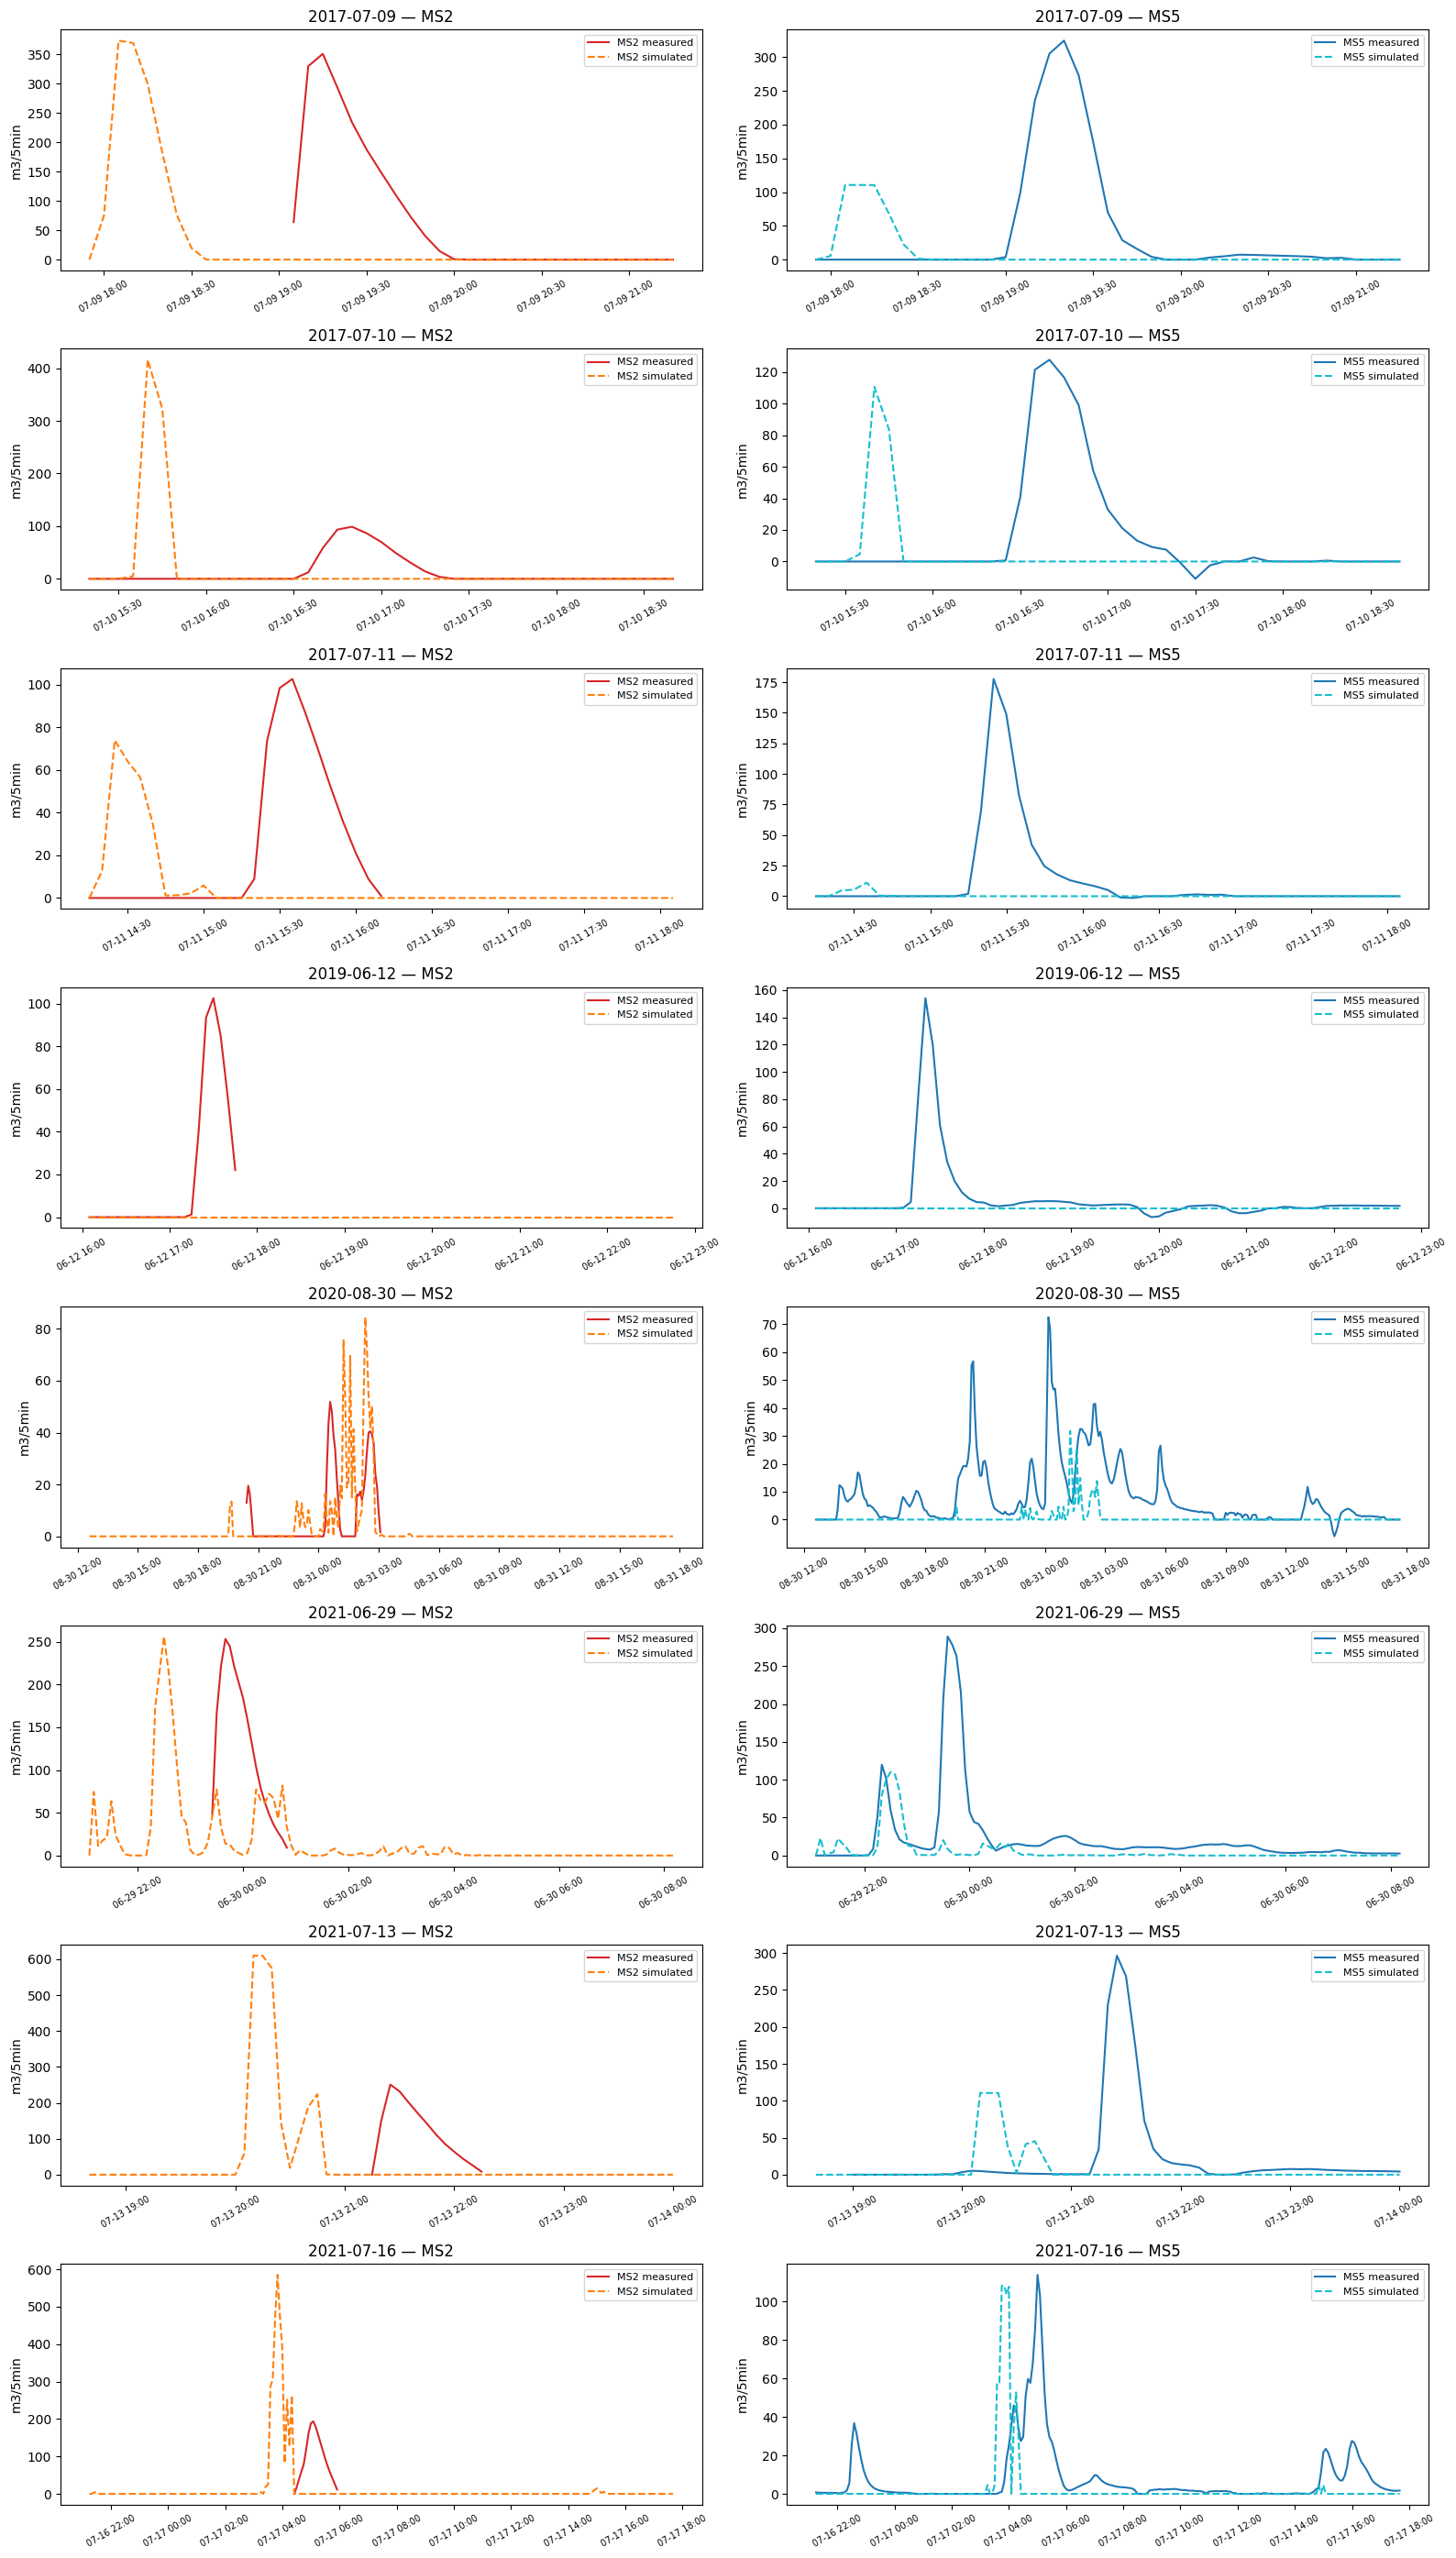

In [24]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

event_results = {}

for event in EVENTS:
    d = np.load(f"{MODEL_DIR}/radolan_aligned/{event}_aligned.npz", allow_pickle=True)
    rain_stack = d["rain_mm"]
    rain_ts = pd.to_datetime(d["timestamps"])

    msd = load_msd_event(EVENT_TO_FILENAME[event])
    msd_window = msd.loc[rain_ts.min():rain_ts.max()]

    result = run_capacity_model(rain_stack, dt_minutes=5, params=PARAM_SETS["run1"])

    event_results[event] = dict(rain_ts=rain_ts, result=result, msd_window=msd_window)
    print(f"{event} done")

fig, axes = plt.subplots(8, 2, figsize=(16, 28))

for i, event in enumerate(EVENTS):
    rain_ts = event_results[event]["rain_ts"]
    result = event_results[event]["result"]
    msd_window = event_results[event]["msd_window"]

    ax = axes[i, 0]
    ax.plot(msd_window.index, msd_window["ms2_m3_per_5min"], color="tab:red", label="MS2 measured")
    ax.plot(rain_ts, result["ms2_total"], color="tab:orange", linestyle="--", label="MS2 simulated")
    ax.set_title(f"{event} — MS2")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.set_ylabel("m3/5min")

    ax = axes[i, 1]
    ax.plot(msd_window.index, msd_window["ms5_m3_per_5min"], color="tab:blue", label="MS5 measured")
    ax.plot(rain_ts, result["ms5_total"], color="tab:cyan", linestyle="--", label="MS5 simulated")
    ax.set_title(f"{event} — MS5")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.set_ylabel("m3/5min")

plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/../baseline_model_all_events.png", dpi=120)
plt.show()

since the sumary and plot's results are not good. I decided to check the RADOLAN_alighned.npz files

In [21]:
d = np.load(f"{MODEL_DIR}/radolan_aligned/2019-06-12_aligned.npz", allow_pickle=True)
rain_stack = d["rain_mm"]

max_in_ms2 = rain_stack[:, ms2_mask].max()
max_in_ms5 = rain_stack[:, ms5_mask].max()
max_overall = rain_stack.max()

print(f"Max cell value anywhere in domain: {max_overall:.2f} mm/5min")
print(f"Max cell value inside MS2 footprint: {max_in_ms2:.2f} mm/5min")
print(f"Max cell value inside MS5 footprint: {max_in_ms5:.2f} mm/5min")
print(f"(threshold_mm=5 in run1/run2 needs a cell to exceed this before any sewer drainage activates)")

Max cell value anywhere in domain: 7.30 mm/5min
Max cell value inside MS2 footprint: 3.77 mm/5min
Max cell value inside MS5 footprint: 2.54 mm/5min
(threshold_mm=5 in run1/run2 needs a cell to exceed this before any sewer drainage activates)


I have rerun and it seems better. I will leave this model stop here and move on the next one.